# XPR (X-Ray Reflectivity Simulation) Demo #

Below contains a few examples demonstrating the functionality of the Julia-based `XPR` package. It is capable of simulating reflectivity from arbitrary $n$-box models with the option to include a protein structure. In every case, the resultant likeliehood function is continuously differentiable with respect to the fitting parameters, no matter the configuration. Accordingly, gradients and Hessians are also available for each point.

To make sure the code runs properly, please ensure you have created and activate a python environment using the `requirements.txt` file.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from XPRsim import XPRsim

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## 2-Box Lipid Baseline ##

Using data from a lipid-only reflectivity experiment (`test_data/2box.rrf`), we can construct an instance with a 2-box model. Instantiating the class will output the active (tunable) parameters and their bounds. Note that by default, `XPRsim` will assume $\sigma$ (interfacial thermodynamic smearing factor), $y_{scale}$ and $bkg$ (linear scaling of reflectivity) are fixed. The log-likelihood and gradient are evaulated by passing in a list of floats.

In [ ]:
model_2box = XPRsim(
    rrf_file='test_data/2box.rrf', 
    num_boxes=2
)

# parameters: [q_offset, L1, L2, rho1, rho2]
# use a best-fit point
params_2box = [-0.0005197557108984115, 12.870861541436838, 9.400266410116624, 0.21726162435306018, 0.4564847693916873]

# compute the log-likelihood, simulated relfectivity, and gradient
logL, R = model_2box.eval_logL(params_2box)
grad = model_2box.eval_grad(params_2box)

print(f"Log-Likelihood: {logL:.4f}")
print(f"Gradient Vector (length {len(grad)}): \n{grad}")

  Activating project at `~/Desktop/gupload/XPR`


XPRsim Initialized Successfully.
----------------------------------------
Total Active Parameters: 5
Expected Input Vector Order & Bounds (modifiable in XPRsim.py):
  [0] q_offset       : [-0.01  0.01]
  [1] box_length_1   : [ 0. 30.]
  [2] box_length_2   : [ 0. 30.]
  [3] box_density_1  : [0. 1.]
  [4] box_density_2  : [0. 1.]
----------------------------------------
Log-Likelihood: -1214.2981
Gradient Vector (length 5): 
[-5.73072840e-03  2.71224575e-07 -4.22689705e-08 -1.38616928e-05
 -9.11472682e-07]


The first function call will take longer due to compilation, but subsequent calls are much faster. We can plot the simulated reflectivity against the measured:

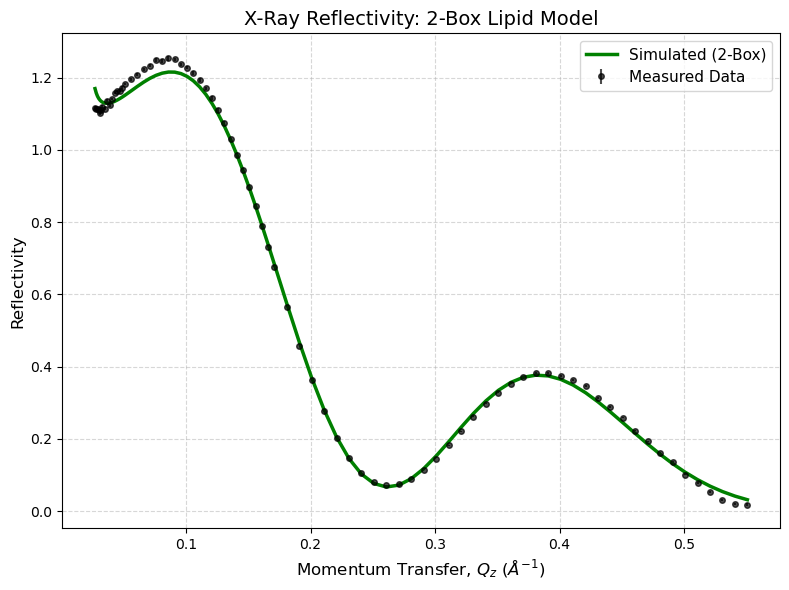

In [ ]:
# extract the measured data from the class variables
Q_measured = model_2box.data_Q
R_measured = model_2box.data_R
R_err = model_2box.data_err

# plot measured data with error bars
fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(Q_measured, R_measured, yerr=R_err, fmt='o', markersize=4, 
            color='gray', label='Measured Data', alpha=0.7)
ax.plot(Q_measured, R, color='green', linewidth=2.5, label='Simulated (2-Box)')
ax.set_xlabel(r'Momentum Transfer, $Q_z$ ($\AA^{-1}$)', fontsize=12)
ax.set_ylabel('Reflectivity', fontsize=12)
ax.set_title('X-Ray Reflectivity: 2-Box Lipid Model', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3-Box Lipid (Fitting Sigma) ##

The option to fit $\sigma$, the thermodynamic smearing factor, is available, as see with data from a 3-box experiment. Additionally, one can toggle the electron densities of the top substrate (default is air and a value of 0) and buffer/bulk/bottom substrate (default is water at 0.334).

In [ ]:
model_3box = XPRsim(
    rrf_file='test_data/3box.rrf', 
    num_boxes=3, 
    fit_sig=True,
    rho_top=0.2574
)

# parameters: [q_offset, sigma, L1, L2, L3, rho1, rho2, rho3]
# using a best-fit point 
params_3box = [0.0008998796447718044, 2.511818916572768, 26.886814178891647, 18.579820992512868, 11.532122447496487,
      0.30077908545466, 0.25596604523845007, 0.31662370213285806]

logL, R = model_3box.eval_logL(params_3box)
print(f"Log-Likelihood: {logL:.4f}")


  Activating project at `~/Desktop/gupload/XPR`


XPRsim Initialized Successfully.
----------------------------------------
Total Active Parameters: 8
Expected Input Vector Order & Bounds (modifiable in XPRsim.py):
  [0] q_offset       : [-0.01  0.01]
  [1] sigma          : [1. 5.]
  [2] box_length_1   : [ 0. 30.]
  [3] box_length_2   : [ 0. 30.]
  [4] box_length_3   : [ 0. 30.]
  [5] box_density_1  : [0. 1.]
  [6] box_density_2  : [0. 1.]
  [7] box_density_3  : [0. 1.]
----------------------------------------
Log-Likelihood: -600.6506


Note that instantiating the model will dynamically dictate the order of parameters.

## 4-Box Lipid (Fitting yscl, bkg) ##

In the 4 box example, we also compute the Hessian, and demonstrate fitting the linear scaling parameters.

In [5]:
model_4box = XPRsim(
    rrf_file='test_data/4box.rrf', 
    num_boxes=4, 
    fit_yscl=True, 
    fit_bkg=True
)

# parameters: [q_offset, yscl, bkg, L1, L2, L3, L4, rho1, rho2, rho3, rho4]
# random point
params_4box = [0.0, 1.05, 1e-6, 8.0, 8.0, 8.0, 8.0, 0.1, 0.2, 0.3, 0.4]

logL, R = model_4box.eval_logL(params_4box)
hess = model_4box.eval_hess(params_4box)

print(f"Log-Likelihood: {logL:.4f}")
print(f"Hessian Matrix Shape: {hess.shape}")

XPRsim Initialized Successfully.
----------------------------------------
Total Active Parameters: 11
Expected Input Vector Order & Bounds (modifiable in XPRsim.py):
  [0] q_offset       : [-0.01  0.01]
  [1] yscl           : [0. 5.]
  [2] bkg            : [-5.  5.]
  [3] box_length_1   : [ 0. 30.]
  [4] box_length_2   : [ 0. 30.]
  [5] box_length_3   : [ 0. 30.]
  [6] box_length_4   : [ 0. 30.]
  [7] box_density_1  : [0. 1.]
  [8] box_density_2  : [0. 1.]
  [9] box_density_3  : [0. 1.]
  [10] box_density_4  : [0. 1.]
----------------------------------------


  Activating project at `~/Desktop/gupload/XPR`


Log-Likelihood: -62408.5320
Hessian Matrix Shape: (11, 11)


## Protein-bound lipid: 2 box ##

In its fullest capabilities, we can include a protein `.pdb` file into the analysis, specifying how to compute its cross-sectional volume.

In [6]:
model_protein = XPRsim(
    rrf_file='test_data/protein_2box.rrf', 
    num_boxes=2, 
    pdb_file='test_data/protein.pdb',
    vol_calc="approx"  
)

# parameters: [q_offset, theta, phi, d_protein, C,  L1, L2, rho1, rho2]
# use a best-fit point
params_protein = [0.0002054238403330481, 32.92088491028436, 112.59475254401123, 13.358030329245691, 2.20516005726808, 
      11.66753477743085, 9.643473851409357, 0.21702095531305382, 0.4470646192673328]

logL, R = model_protein.eval_logL(params_protein)

print(f"Log-Likelihood: {logL:.4f}")

  Activating project at `~/Desktop/gupload/XPR`


XPRsim Initialized Successfully.
----------------------------------------
Total Active Parameters: 9
Expected Input Vector Order & Bounds (modifiable in XPRsim.py):
  [0] q_offset       : [-0.01  0.01]
  [1] theta (deg)    : [  0. 180.]
  [2] phi (deg)      : [  0. 360.]
  [3] d_protein      : [ 0. 20.]
  [4] coverage_C     : [ 0. 10.]
  [5] box_length_1   : [ 0. 30.]
  [6] box_length_2   : [ 0. 30.]
  [7] box_density_1  : [0. 1.]
  [8] box_density_2  : [0. 1.]
----------------------------------------
Log-Likelihood: -466.4557
